In [ ]:
# DuckDB: an in-process SQL engine, good for querying CSVs directly without a server
import duckdb


In [6]:
# Opens (or creates) a local database file to hold the loaded table
con = duckdb.connect("cosmetics.duckdb")

In [14]:
# All 5 monthly files share the same schema, one continuous event stream split
# by month, so load them into a single table using DuckDB's glob support to
# read every CSV in the folder in one shot
con.execute("""
    CREATE OR REPLACE TABLE events AS
    SELECT * FROM read_csv_auto('../data/cosmetics/*.csv')
""")

In [15]:
# Confirm the table loaded successfully
con.sql("SHOW TABLES")


┌─────────┐
│  name   │
│ varchar │
├─────────┤
│ events  │
└─────────┘

In [16]:
# Total row count across all 5 months combined
con.sql("SELECT COUNT(*) AS n FROM events")



┌──────────┐
│    n     │
│  int64   │
├──────────┤
│ 20692840 │
└──────────┘

In [17]:
# Check column names and types before writing queries against this table
con.sql("DESCRIBE events")

┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ event_time    │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ event_type    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ product_id    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ category_id   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ category_code │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ brand         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ price         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ user_id       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ user_session  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴───

In [18]:
# See what values event_type takes and how many rows fall in each,
# this is the raw material for the funnel (view -> cart -> purchase)
con.sql("""
    SELECT event_type, COUNT(*) AS n
    FROM events
    GROUP BY event_type
    ORDER BY n DESC
""")

┌──────────────────┬─────────┐
│    event_type    │    n    │
│     varchar      │  int64  │
├──────────────────┼─────────┤
│ view             │ 9657821 │
│ cart             │ 5768333 │
│ remove_from_cart │ 3979679 │
│ purchase         │ 1287007 │
└──────────────────┴─────────┘

In [19]:
# Check the date range this data actually covers, and null counts for the
# columns most likely to have gaps (category_code and brand are known to be
# sparse in this kind of clickstream export)
con.sql("""
    SELECT
        MIN(event_time) AS earliest,
        MAX(event_time) AS latest,
        COUNT(*) FILTER (WHERE category_code IS NULL) AS missing_category_code,
        COUNT(*) FILTER (WHERE brand IS NULL) AS missing_brand,
        COUNT(*) FILTER (WHERE user_session IS NULL) AS missing_session
    FROM events
""")


┌─────────────────────┬─────────────────────┬───────────────────────┬───────────────┬─────────────────┐
│      earliest       │       latest        │ missing_category_code │ missing_brand │ missing_session │
│      timestamp      │      timestamp      │         int64         │     int64     │      int64      │
├─────────────────────┼─────────────────────┼───────────────────────┼───────────────┼─────────────────┤
│ 2019-10-01 00:00:00 │ 2020-02-29 23:59:59 │              20339246 │       8757117 │            4598 │
└─────────────────────┴─────────────────────┴───────────────────────┴───────────────┴─────────────────┘

In [20]:
# user_id is the other essential column for retention/cohort analysis,
# confirm it's not missing anywhere either
con.sql("SELECT COUNT(*) FILTER (WHERE user_id IS NULL) AS missing_user_id FROM events")

┌─────────────────┐
│ missing_user_id │
│      int64      │
├─────────────────┤
│               0 │
└─────────────────┘

### What the loaded data looks like

The five monthly files combine into one table of 20,692,840 events, running from
October 1, 2019 through February 29, 2020 with no gaps at either end.

`event_type` splits into four values: view (9.66M), cart (5.77M), remove_from_cart
(3.98M), and purchase (1.29M). Cart isn't a one-way step toward purchase here,
since items can get removed again, so the funnel logic needs to account for that
rather than assuming a straight line from view to cart to purchase.

Two columns have real gaps. `category_code` is missing in 98.3% of rows, so any
category-level breakdown would be built on a tiny sliver of the data and isn't
worth relying on. `brand` is missing 42% of the time, usable but incomplete.
`user_session` is essentially complete, and that's the column the funnel logic
actually depends on, along with `user_id` for anything cohort-based later.

In [21]:
# Count total sessions and how many reached each funnel stage at least once.
# A session counts as reaching a stage if it has any event of that type,
# regardless of what happened after (cart-then-removed still reached cart)
con.sql("""
    SELECT
        COUNT(DISTINCT user_session) AS total_sessions,
        COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_session END) AS sessions_with_view,
        COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS sessions_with_cart,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS sessions_with_purchase
    FROM events
    WHERE user_session IS NOT NULL
""")

┌────────────────┬────────────────────┬────────────────────┬────────────────────────┐
│ total_sessions │ sessions_with_view │ sessions_with_cart │ sessions_with_purchase │
│     int64      │       int64        │       int64        │         int64          │
├────────────────┼────────────────────┼────────────────────┼────────────────────────┤
│        4535941 │            4280701 │             985780 │                 155617 │
└────────────────┴────────────────────┴────────────────────┴────────────────────────┘

In [22]:
# Save the funnel stage counts as a view: total sessions, and how many
# reached each stage at least once
con.execute("""
    CREATE OR REPLACE VIEW session_funnel_counts AS
    SELECT
        COUNT(DISTINCT user_session) AS total_sessions,
        COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_session END) AS sessions_with_view,
        COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_session END) AS sessions_with_cart,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) AS sessions_with_purchase
    FROM events
    WHERE user_session IS NOT NULL
""")

In [23]:
# Convert the raw counts into conversion rates between stages, both against
# total sessions and against the stage right before it
con.sql("""
    SELECT
        total_sessions,
        ROUND(sessions_with_view * 100.0 / total_sessions, 1) AS pct_view,
        ROUND(sessions_with_cart * 100.0 / total_sessions, 1) AS pct_cart_of_total,
        ROUND(sessions_with_cart * 100.0 / sessions_with_view, 1) AS pct_cart_of_viewers,
        ROUND(sessions_with_purchase * 100.0 / total_sessions, 1) AS pct_purchase_of_total,
        ROUND(sessions_with_purchase * 100.0 / sessions_with_cart, 1) AS pct_purchase_of_carters
    FROM session_funnel_counts
""")

┌────────────────┬──────────┬───────────────────┬─────────────────────┬───────────────────────┬─────────────────────────┐
│ total_sessions │ pct_view │ pct_cart_of_total │ pct_cart_of_viewers │ pct_purchase_of_total │ pct_purchase_of_carters │
│     int64      │  double  │      double       │       double        │        double         │         double          │
├────────────────┼──────────┼───────────────────┼─────────────────────┼───────────────────────┼─────────────────────────┤
│        4535941 │     94.4 │              21.7 │                23.0 │                   3.4 │                    15.8 │
└────────────────┴──────────┴───────────────────┴─────────────────────┴───────────────────────┴─────────────────────────┘

### The funnel, measured

Out of 4,535,941 sessions, 94.4% include at least one view event, but only
23.0% of those go on to add something to a cart. Of the sessions that do cart,
only 15.8% convert to a purchase. Overall, 3.4% of sessions end in a purchase.

The biggest drop happens between viewing and carting, not between carting and
buying. Two-thirds of sessions that view a product never interact with a cart
at all. That's a different story than the old planning numbers assumed
($24M of $29.9M cart value abandoned), which was framed around cart abandonment
specifically. The real leak here is earlier in the funnel, before anything
ever reaches a cart.

In [24]:
# Check whether repeat purchasing actually happens in this data: for each
# purchaser, count how many distinct calendar months they bought in, then see
# what share of purchasers show up in more than one month
con.sql("""
    WITH purchaser_months AS (
        SELECT
            user_id,
            COUNT(DISTINCT DATE_TRUNC('month', event_time)) AS distinct_purchase_months
        FROM events
        WHERE event_type = 'purchase'
        GROUP BY user_id
    )
    SELECT
        COUNT(*) AS total_purchasers,
        COUNT(*) FILTER (WHERE distinct_purchase_months > 1) AS repeat_month_purchasers,
        ROUND(COUNT(*) FILTER (WHERE distinct_purchase_months > 1) * 100.0 / COUNT(*), 1) AS repeat_pct
    FROM purchaser_months
""")

┌──────────────────┬─────────────────────────┬────────────┐
│ total_purchasers │ repeat_month_purchasers │ repeat_pct │
│      int64       │          int64          │   double   │
├──────────────────┼─────────────────────────┼────────────┤
│           110518 │                   17720 │       16.0 │
└──────────────────┴─────────────────────────┴────────────┘

In [25]:
# Assign each purchaser to a cohort based on the calendar month of their
# first purchase
con.execute("""
    CREATE OR REPLACE VIEW purchaser_cohorts AS
    SELECT
        user_id,
        DATE_TRUNC('month', MIN(event_time)) AS cohort_month
    FROM events
    WHERE event_type = 'purchase'
    GROUP BY user_id
""")

In [26]:
con.execute("""
    CREATE OR REPLACE VIEW cohort_retention_counts AS
    SELECT
        c.cohort_month,
        DATE_DIFF('month', c.cohort_month, DATE_TRUNC('month', e.event_time)) AS month_offset,
        COUNT(DISTINCT e.user_id) AS active_purchasers
    FROM events e
    JOIN purchaser_cohorts c ON e.user_id = c.user_id
    WHERE e.event_type = 'purchase'
    GROUP BY c.cohort_month, month_offset
""")

con.sql("SELECT * FROM cohort_retention_counts ORDER BY cohort_month, month_offset")

┌─────────────────────┬──────────────┬───────────────────┐
│    cohort_month     │ month_offset │ active_purchasers │
│      timestamp      │    int64     │       int64       │
├─────────────────────┼──────────────┼───────────────────┤
│ 2019-10-01 00:00:00 │            0 │             25762 │
│ 2019-10-01 00:00:00 │            1 │              4763 │
│ 2019-10-01 00:00:00 │            2 │              3293 │
│ 2019-10-01 00:00:00 │            3 │              3399 │
│ 2019-10-01 00:00:00 │            4 │              2692 │
│ 2019-11-01 00:00:00 │            0 │             26761 │
│ 2019-11-01 00:00:00 │            1 │              2618 │
│ 2019-11-01 00:00:00 │            2 │              2716 │
│ 2019-11-01 00:00:00 │            3 │              2119 │
│ 2019-12-01 00:00:00 │            0 │             19702 │
│ 2019-12-01 00:00:00 │            1 │              1678 │
│ 2019-12-01 00:00:00 │            2 │              1272 │
│ 2020-01-01 00:00:00 │            0 │             20427

In [27]:
# Turn the raw counts into retention percentages: what share of each
# cohort's original size was still purchasing N months later
con.execute("""
    CREATE OR REPLACE VIEW cohort_retention_pct AS
    SELECT
        r.cohort_month,
        r.month_offset,
        r.active_purchasers,
        s.cohort_size,
        ROUND(r.active_purchasers * 100.0 / s.cohort_size, 1) AS retention_pct
    FROM cohort_retention_counts r
    JOIN (
        SELECT cohort_month, active_purchasers AS cohort_size
        FROM cohort_retention_counts
        WHERE month_offset = 0
    ) s ON r.cohort_month = s.cohort_month
""")

con.sql("SELECT * FROM cohort_retention_pct ORDER BY cohort_month, month_offset")

┌─────────────────────┬──────────────┬───────────────────┬─────────────┬───────────────┐
│    cohort_month     │ month_offset │ active_purchasers │ cohort_size │ retention_pct │
│      timestamp      │    int64     │       int64       │    int64    │    double     │
├─────────────────────┼──────────────┼───────────────────┼─────────────┼───────────────┤
│ 2019-10-01 00:00:00 │            0 │             25762 │       25762 │         100.0 │
│ 2019-10-01 00:00:00 │            1 │              4763 │       25762 │          18.5 │
│ 2019-10-01 00:00:00 │            2 │              3293 │       25762 │          12.8 │
│ 2019-10-01 00:00:00 │            3 │              3399 │       25762 │          13.2 │
│ 2019-10-01 00:00:00 │            4 │              2692 │       25762 │          10.4 │
│ 2019-11-01 00:00:00 │            0 │             26761 │       26761 │         100.0 │
│ 2019-11-01 00:00:00 │            1 │              2618 │       26761 │           9.8 │
│ 2019-11-01 00:00:00

### Retention doesn't decay smoothly, it drops sharply after one cohort

Month-1 retention lands at 18.5% for the October cohort, then drops into
single digits and stays there: 9.8% for November, 8.5% for December, 8.9%
for January. Instead of a steady decline across cohorts, there's one sharp
step down after October and then a flat floor around 8 to 10% for every
cohort after it.

October also holds up unusually well over time. Its retention actually
ticks up slightly at month 3 (13.2%, higher than month 2's 12.8%) before
dropping again at month 4. None of the other cohorts show that bump, they
decline in more or less straight lines. Whether that's a seasonal effect,
holiday shoppers behaving differently from earlier buyers, or something
specific to that cohort's size and makeup isn't something this data can
answer on its own, but it's a real break in the pattern worth noting rather
than smoothing over.

Either way, the headline number is that roughly 9 in 10 purchasers, no
matter which month they first bought in, don't come back the following
month.

In [28]:
# Pull retention percentages for charting, excluding the most recent cohort
# since it has no later months yet to show any trend
retention_df = con.sql("""
    SELECT cohort_month, month_offset, retention_pct
    FROM cohort_retention_pct
    WHERE cohort_month < (SELECT MAX(cohort_month) FROM cohort_retention_pct)
    ORDER BY cohort_month, month_offset
""").df()

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

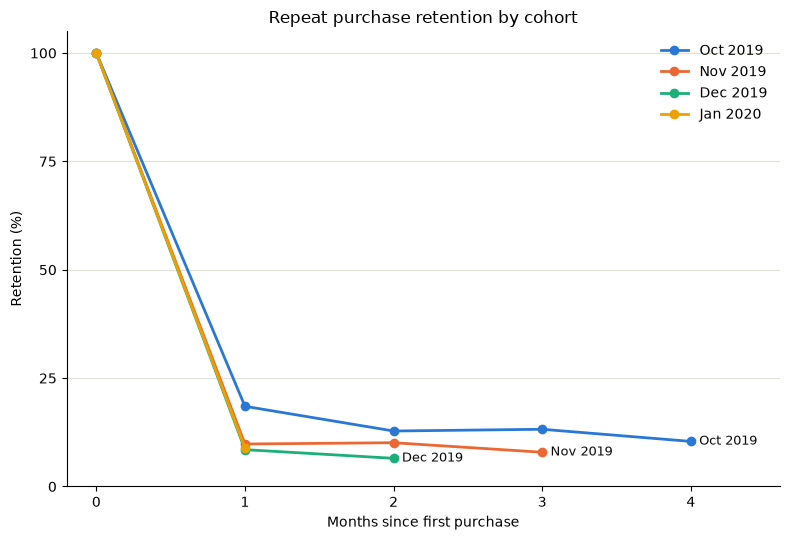

In [32]:
# One fixed color per cohort, chosen to stay distinguishable under color
# blindness rather than picked by eye
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
cohorts = sorted(retention_df["cohort_month"].unique())

fig, ax = plt.subplots(figsize=(8, 5.5))

for color, cohort in zip(colors, cohorts):
    sub = retention_df[retention_df["cohort_month"] == cohort].sort_values("month_offset")
    label = pd.Timestamp(cohort).strftime("%b %Y")
    ax.plot(sub["month_offset"], sub["retention_pct"], color=color, linewidth=2,
            marker="o", markersize=6, label=label)
    # Skip the direct label for cohorts with only one month of follow-up,
    # their endpoint sits right where the other lines are still crossing
    if sub["month_offset"].max() >= 2:
        last = sub.iloc[-1]
        ax.annotate(label, xy=(last["month_offset"], last["retention_pct"]),
                    xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color="#0b0b0b")

ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Retention (%)")
ax.set_title("Repeat purchase retention by cohort")
ax.set_xticks(range(0, int(retention_df["month_offset"].max()) + 1))
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_ylim(0, 105)
ax.set_xlim(right=retention_df["month_offset"].max() + 0.6)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("retention_by_cohort.png", dpi=150, bbox_inches="tight")
plt.show()

### Retention chart, and what it confirms

The chart makes the same story the numbers told, but easier to see at a
glance: every cohort falls off a cliff between month 0 and month 1, then the
survivors settle onto a low, mostly flat floor rather than continuing to
decline. October is the one cohort that visibly separates from the rest and
stays separated, it's the highest line in the chart from month 1 onward,
including that small uptick at month 3 that shows up as a real bump in the
line, not just a number in a table.

November, December, and January cluster tightly together in the 6 to 10%
band, close enough that their exact ordering matters less than the fact that
none of them come close to October's retention. Whatever made the October
cohort different, it isn't something that shows up again in the months
after it.

In [33]:
# Reshape the funnel counts into one row per stage, in funnel order, both
# as a percentage of total sessions and the raw count
funnel_df = con.sql("""
    SELECT 1 AS stage_order, 'All sessions' AS stage, total_sessions AS n, 100.0 AS pct FROM session_funnel_counts
    UNION ALL
    SELECT 2, 'Viewed', sessions_with_view, sessions_with_view * 100.0 / total_sessions FROM session_funnel_counts
    UNION ALL
    SELECT 3, 'Added to cart', sessions_with_cart, sessions_with_cart * 100.0 / total_sessions FROM session_funnel_counts
    UNION ALL
    SELECT 4, 'Purchased', sessions_with_purchase, sessions_with_purchase * 100.0 / total_sessions FROM session_funnel_counts
    ORDER BY stage_order
""").df()

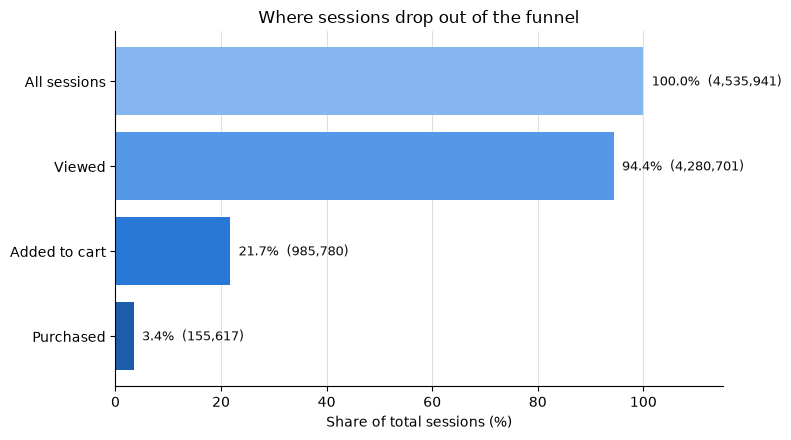

In [34]:
import matplotlib.pyplot as plt

# One hue, stepped light to dark, since these are ordered stages of a
# single funnel rather than separate categories being compared
ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel_df["stage"], funnel_df["pct"], color=ramp)
ax.invert_yaxis()  # "All sessions" reads at top, "Purchased" at bottom

# Label each bar with its percentage and raw session count
for bar, pct, n in zip(bars, funnel_df["pct"], funnel_df["n"]):
    ax.annotate(f"{pct:.1f}%  ({n:,.0f})", xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color="#0b0b0b")

ax.set_xlabel("Share of total sessions (%)")
ax.set_title("Where sessions drop out of the funnel")
ax.set_xlim(0, 115)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("funnel_dropoff.png", dpi=150, bbox_inches="tight")
plt.show()

### The funnel chart makes the real leak obvious

Almost every session views something, 94.4% of them. The drop that actually
matters happens right after that: only 21.7% of sessions ever add anything
to a cart, meaning close to three out of every four sessions that view a
product never interact with a cart at all. From there, cart to purchase is a
comparatively gentle slope, 21.7% down to 3.4%, roughly 1 in 6 carting
sessions convert.

That reframes where the opportunity actually sits. Cart abandonment gets
most of the attention in e-commerce writing, but for this shop the bigger
leak is upstream of the cart entirely, in whatever makes someone look at a
product and walk away without even considering buying it.

In [35]:
# Sum cart value per session, and flag whether that session ever purchased.
# Sessions with no cart activity at all get excluded by the WHERE below,
# since a cart_value of NULL/0 there isn't meaningful
con.execute("""
    CREATE OR REPLACE VIEW session_cart_value AS
    SELECT
        user_session,
        SUM(price) FILTER (WHERE event_type = 'cart') AS cart_value,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchased
    FROM events
    WHERE user_session IS NOT NULL
    GROUP BY user_session
""")


In [36]:
# Split total cart value into what converted vs what never did, plus the
# share abandoned
con.sql("""
    SELECT
        ROUND(SUM(cart_value) FILTER (WHERE purchased = 0), 2) AS abandoned_cart_value,
        ROUND(SUM(cart_value) FILTER (WHERE purchased = 1), 2) AS converted_cart_value,
        ROUND(SUM(cart_value), 2) AS total_cart_value,
        ROUND(SUM(cart_value) FILTER (WHERE purchased = 0) * 100.0 / SUM(cart_value), 1) AS pct_abandoned
    FROM session_cart_value
    WHERE cart_value > 0
""")

┌──────────────────────┬──────────────────────┬──────────────────┬───────────────┐
│ abandoned_cart_value │ converted_cart_value │ total_cart_value │ pct_abandoned │
│        double        │        double        │      double      │    double     │
├──────────────────────┼──────────────────────┼──────────────────┼───────────────┤
│          23993092.16 │           5870756.97 │      29863849.13 │          80.3 │
└──────────────────────┴──────────────────────┴──────────────────┴───────────────┘

In [37]:
# Actual revenue from completed purchases, as a separate check, this isn't
# necessarily equal to converted_cart_value above since a purchase doesn't
# have to be preceded by a cart event in the same session
con.sql("SELECT ROUND(SUM(price), 2) AS total_revenue FROM events WHERE event_type = 'purchase'")

┌───────────────┐
│ total_revenue │
│    double     │
├───────────────┤
│    6348004.87 │
└───────────────┘

### Cart value: how much is actually walking away

Of $29,863,849 in cart value across the five months, $23,993,092 was never
converted to a purchase, 80.3%. Actual purchase revenue for the same period
comes in at $6,348,005, a bit higher than the $5,870,757 in cart value tied
to sessions that did convert, meaning some purchases happened without a
matching cart event in that same session, likely a direct buy, or an item
carted during an earlier visit that this session-level view can't connect
to the purchase that followed.

Note: the source dataset doesn't document its currency explicitly. USD is
assumed here as the most likely convention for this kind of dataset, not a
confirmed fact.